## 1. Import Libraries and Setup

In [324]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import numpy as np
import os
import random
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

# Configuration
FONT_PATHS = glob('../assets/*.ttf', recursive=True)
IMAGE_SIZE = (28, 28)
BASE_FONT_SIZE = 25

print(f"Found {len(FONT_PATHS)} font files")
if FONT_PATHS:
    print(f"Sample font: {os.path.basename(FONT_PATHS[0])}")

Found 5 font files
Sample font: MaruBuri-Bold.ttf


## 2. Augmentation Parameters Configuration

**Adjust these parameters to control augmentation intensity:**

In [325]:
# ============================================================
# Augmentation Range Settings
# ============================================================
# Adjust these values to control the strength of each augmentation

# 1. Rotation Range (degrees)
ROTATION_RANGE = (-20, 20)  # Min and max rotation angle

# 2. Font Size Range
FONT_SIZE_RANGE = (20, 30)  # Min and max font size

# 3. Position Offset Range
POSITION_X_RANGE = (-7, 7)  # Horizontal offset (pixels) , Edge : -7, 7
POSITION_Y_RANGE = (-6, 6)  # Vertical offset (pixels) , Edge : -12 , 0

# 4. Blur Range
BLUR_RADIUS_RANGE = (0, 0.8)  # Gaussian blur radius (0 = no blur)

# 5. Dataset Generation
VARIATIONS_PER_DIGIT = 3  # Number of variations per digit per font

# ============================================================
# Display current settings
# ============================================================
print("Current Augmentation Settings:")
print("=" * 50)
print(f"Rotation Range:     {ROTATION_RANGE[0]}° to {ROTATION_RANGE[1]}°")
print(f"Font Size Range:    {FONT_SIZE_RANGE[0]} to {FONT_SIZE_RANGE[1]}")
print(f"Position X Range:   {POSITION_X_RANGE[0]} to {POSITION_X_RANGE[1]} pixels")
print(f"Position Y Range:   {POSITION_Y_RANGE[0]} to {POSITION_Y_RANGE[1]} pixels")
print(f"Blur Radius Range:  {BLUR_RADIUS_RANGE[0]} to {BLUR_RADIUS_RANGE[1]}")
print(f"Variations/Digit:   {VARIATIONS_PER_DIGIT}")
print("=" * 50)

Current Augmentation Settings:
Rotation Range:     -20° to 20°
Font Size Range:    20 to 30
Position X Range:   -7 to 7 pixels
Position Y Range:   -6 to 6 pixels
Blur Radius Range:  0 to 0.8
Variations/Digit:   3


## 2. Base Function - Generate Simple Digit Image

In [326]:
def generate_base_digit(digit, font_path, font_size=25, canvas_size=(28, 28)):
    """
    Generate a base digit image without augmentation.
    
    Args:
        digit (int): Digit to generate (0-9)
        font_path (str): Path to the font file
        font_size (int): Font size
        canvas_size (tuple): Image size
    
    Returns:
        PIL.Image: Generated image
    """
    image = Image.new("L", canvas_size, 255)
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype(font_path, font_size)
    except IOError:
        print(f"Failed to load font: {font_path}")
        return None
    
    # Calculate text position (centered)
    bbox = draw.textbbox((0, 0), str(digit), font=font)
    text_width = bbox[2] - bbox[0]
    
    # Position: horizontally centered, vertically at top with -3 offset
    position = (
        (canvas_size[0] - text_width) // 2,
        -3
    )
    
    draw.text(position, str(digit), fill=0, font=font)
    
    return image

## 3. Augmentation Function 1: Rotation

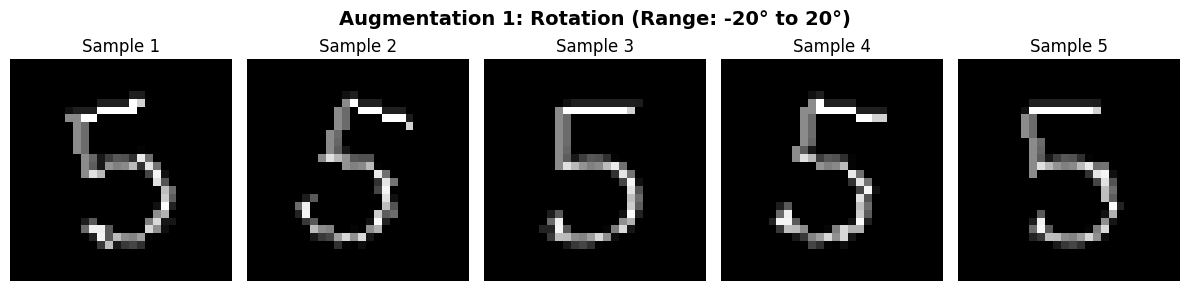

In [327]:
def apply_rotation(image, angle_range=(-20, 20)):
    """
    Apply random rotation to the image.
    
    Args:
        image (PIL.Image): Input image
        angle_range (tuple): Min and max rotation angles in degrees
    
    Returns:
        PIL.Image: Rotated image
    """
    angle = random.uniform(*angle_range)
    rotated = image.rotate(angle, fillcolor=255, expand=False)
    return rotated

# Visualization
if FONT_PATHS:
    test_digit = 5
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f'Augmentation 1: Rotation (Range: {ROTATION_RANGE[0]}° to {ROTATION_RANGE[1]}°)', 
                 fontsize=14, fontweight='bold')
    
    for i, ax in enumerate(axes):
        base_img = generate_base_digit(test_digit, test_font)
        if base_img:
            rotated_img = apply_rotation(base_img, angle_range=ROTATION_RANGE)
            # Invert for display
            img_array = 255 - np.array(rotated_img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'Sample {i+1}')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 4. Augmentation Function 2: Blur (Edge Contrast)

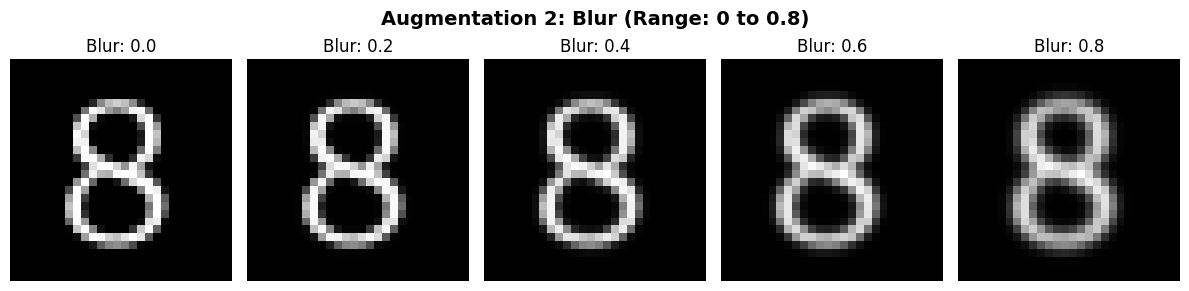

In [328]:
def apply_blur(image, blur_range=(0, 1.0)):
    """
    Apply Gaussian blur to soften edges.
    
    Args:
        image (PIL.Image): Input image
        blur_range (tuple): Min and max blur radius
    
    Returns:
        PIL.Image: Blurred image
    """
    blur_radius = random.uniform(*blur_range)
    if blur_radius > 0.1:
        blurred = image.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        return blurred
    return image

# Visualization
if FONT_PATHS:
    test_digit = 8
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f'Augmentation 2: Blur (Range: {BLUR_RADIUS_RANGE[0]} to {BLUR_RADIUS_RANGE[1]})', 
                 fontsize=14, fontweight='bold')
    
    blur_values = np.linspace(BLUR_RADIUS_RANGE[0], BLUR_RADIUS_RANGE[1], 5)
    
    for i, (ax, blur_val) in enumerate(zip(axes, blur_values)):
        base_img = generate_base_digit(test_digit, test_font)
        if base_img:
            blurred_img = base_img.filter(ImageFilter.GaussianBlur(radius=blur_val))
            img_array = 255 - np.array(blurred_img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'Blur: {blur_val:.1f}')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 5. Augmentation Function 3: Font Size Variation

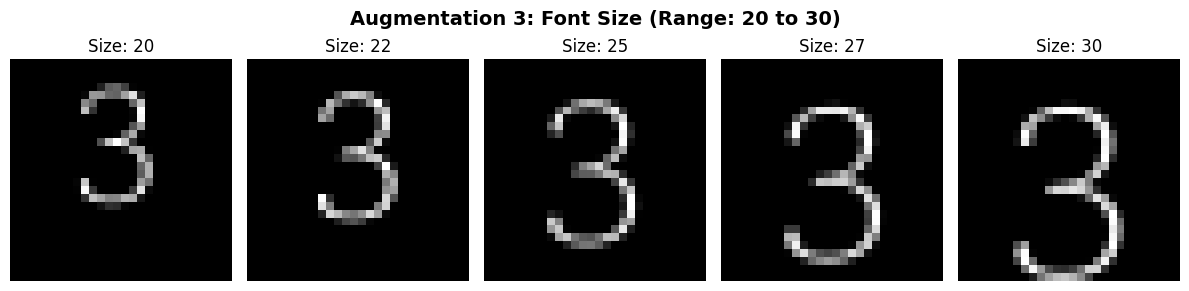

In [329]:
def apply_font_size_variation(digit, font_path, size_range=(18, 32)):
    """
    Generate digit with random font size.
    
    Args:
        digit (int): Digit to generate
        font_path (str): Path to font file
        size_range (tuple): Min and max font size
    
    Returns:
        PIL.Image: Generated image with varied font size
    """
    font_size = random.randint(*size_range)
    return generate_base_digit(digit, font_path, font_size=font_size)

# Visualization
if FONT_PATHS:
    test_digit = 3
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f'Augmentation 3: Font Size (Range: {FONT_SIZE_RANGE[0]} to {FONT_SIZE_RANGE[1]})', 
                 fontsize=14, fontweight='bold')
    
    font_sizes = np.linspace(FONT_SIZE_RANGE[0], FONT_SIZE_RANGE[1], 5, dtype=int)
    
    for i, (ax, font_size) in enumerate(zip(axes, font_sizes)):
        img = generate_base_digit(test_digit, test_font, font_size=font_size)
        if img:
            img_array = 255 - np.array(img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'Size: {font_size}')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 6. Augmentation Function 4: Font Weight Variation

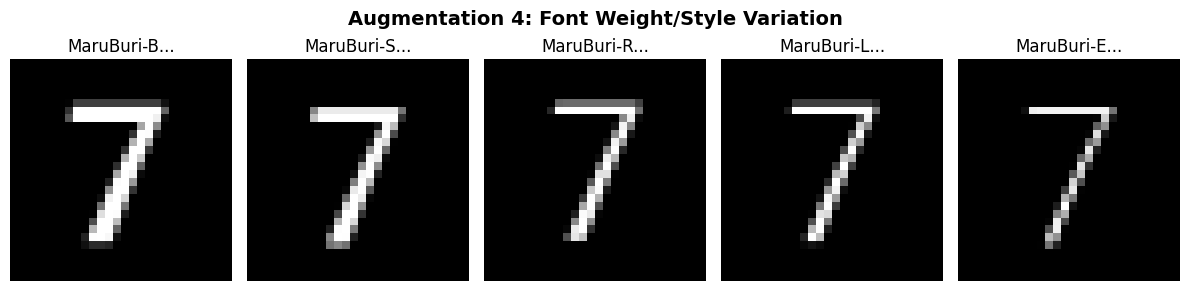

In [330]:
def apply_font_weight_variation(digit, font_paths_list):
    """
    Generate digit using different fonts (weight variation).
    
    Args:
        digit (int): Digit to generate
        font_paths_list (list): List of font file paths
    
    Returns:
        PIL.Image: Generated image with random font
    """
    font_path = random.choice(font_paths_list)
    return generate_base_digit(digit, font_path)

# Visualization
if len(FONT_PATHS) >= 5:
    test_digit = 7
    sample_fonts = random.sample(FONT_PATHS, min(5, len(FONT_PATHS)))
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle('Augmentation 4: Font Weight/Style Variation', fontsize=14, fontweight='bold')
    
    for i, (ax, font_path) in enumerate(zip(axes, sample_fonts)):
        img = generate_base_digit(test_digit, font_path)
        if img:
            img_array = 255 - np.array(img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'{os.path.basename(font_path)[:10]}...')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 7. Augmentation Function 5: Position Variation

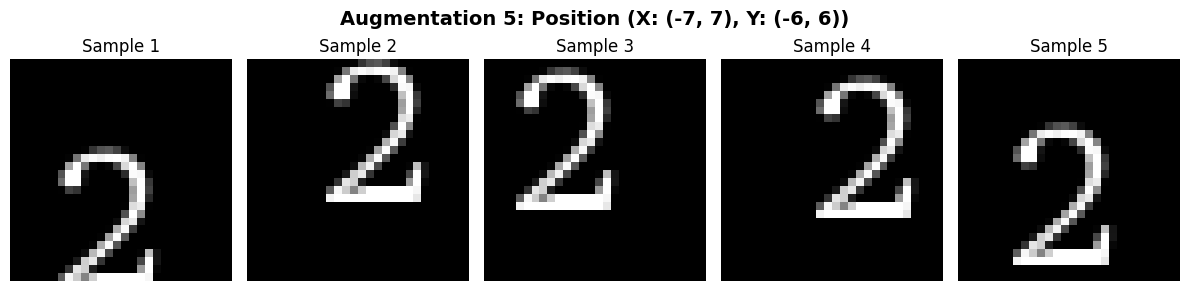

In [331]:
def apply_position_variation(digit, font_path, x_range=(-3, 3), y_range=(-5, 2)):
    """
    Generate digit with random position offset.
    
    Args:
        digit (int): Digit to generate
        font_path (str): Path to font file
        x_range (tuple): Horizontal offset range
        y_range (tuple): Vertical offset range
    
    Returns:
        PIL.Image: Generated image with position offset
    """
    image = Image.new("L", IMAGE_SIZE, 255)
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype(font_path, BASE_FONT_SIZE)
    except IOError:
        return None
    
    bbox = draw.textbbox((0, 0), str(digit), font=font)
    text_width = bbox[2] - bbox[0]
    
    # Random offset
    x_offset = random.randint(*x_range)
    y_offset = random.randint(*y_range)
    
    # Position: horizontally centered + x_offset, vertically at -3 + y_offset
    position = (
        (IMAGE_SIZE[0] - text_width) // 2 + x_offset,
        -3 + y_offset
    )
    
    draw.text(position, str(digit), fill=0, font=font)
    return image

# Visualization
if FONT_PATHS:
    test_digit = 2
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))
    fig.suptitle(f'Augmentation 5: Position (X: {POSITION_X_RANGE}, Y: {POSITION_Y_RANGE})', 
                 fontsize=14, fontweight='bold')
    
    for i, ax in enumerate(axes):
        img = apply_position_variation(test_digit, test_font, x_range=POSITION_X_RANGE, y_range=POSITION_Y_RANGE)
        if img:
            img_array = 255 - np.array(img)
            ax.imshow(img_array, cmap='gray')
            ax.set_title(f'Sample {i+1}')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 8. Combined Augmentation Function

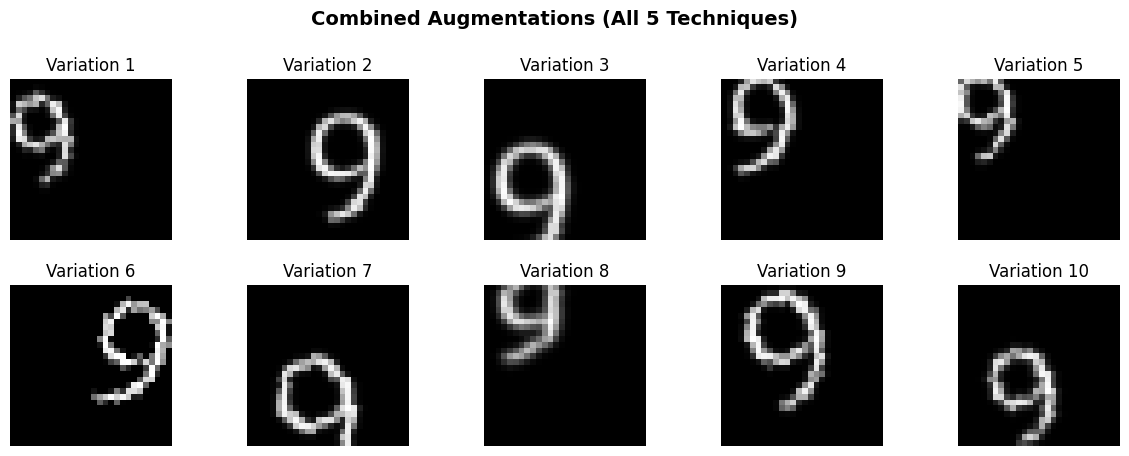

In [332]:
def generate_augmented_digit(digit, font_path, 
                            rotation_range=ROTATION_RANGE,
                            blur_range=BLUR_RADIUS_RANGE,
                            size_range=FONT_SIZE_RANGE,
                            x_range=POSITION_X_RANGE,
                            y_range=POSITION_Y_RANGE):
    """
    Generate a fully augmented digit image with all transformations.
    
    Args:
        digit (int): Digit to generate (0-9)
        font_path (str): Path to the font file
        rotation_range (tuple): Rotation angle range (uses global ROTATION_RANGE if None)
        blur_range (tuple): Blur radius range (uses global BLUR_RADIUS_RANGE if None)
        size_range (tuple): Font size range (uses global FONT_SIZE_RANGE if None)
        x_range (tuple): Horizontal position offset range (uses global POSITION_X_RANGE if None)
        y_range (tuple): Vertical position offset range (uses global POSITION_Y_RANGE if None)
    
    Returns:
        numpy.ndarray: 28x28 grayscale image array
    """
    
    # Random parameters
    font_size = random.randint(*size_range)
    rotation_angle = random.uniform(*rotation_range)
    blur_radius = random.uniform(*blur_range)
    x_offset = random.randint(*x_range)
    y_offset = random.randint(*y_range)
    
    # Create larger canvas for rotation
    canvas_size = (40, 40)
    image = Image.new("L", canvas_size, 255)
    draw = ImageDraw.Draw(image)
    
    try:
        font = ImageFont.truetype(font_path, font_size)
    except IOError:
        return None
    
    # Calculate centered position with offset
    bbox = draw.textbbox((0, 0), str(digit), font=font)
    text_width = bbox[2] - bbox[0]
    
    # Position: horizontally centered + x_offset, vertically at 3 + y_offset
    position = (
        (canvas_size[0] - text_width) // 2 + x_offset,
        3+ y_offset
    )
    
    # Draw text
    draw.text(position, str(digit), fill=0, font=font)
    
    # Apply rotation
    if abs(rotation_angle) > 0.1:
        image = image.rotate(rotation_angle, fillcolor=255, expand=False)
    
    # Apply blur
    if blur_radius > 0.1:
        image = image.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    
    # Crop to 28x28
    left = (canvas_size[0] - IMAGE_SIZE[0]) // 2
    top = (canvas_size[1] - IMAGE_SIZE[1]) // 2
    image = image.crop((left, top, left + IMAGE_SIZE[0], top + IMAGE_SIZE[1]))
    
    # Convert to numpy array and invert
    image_array = np.array(image)
    image_array = 255 - image_array
    
    return image_array

# Visualization - Combined augmentations
if FONT_PATHS:
    test_digit = 9
    test_font = random.choice(FONT_PATHS)
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle('Combined Augmentations (All 5 Techniques)', fontsize=14, fontweight='bold')

    axes = axes.flatten()
    # Reserve space for the suptitle
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    for i, ax in enumerate(axes):
        ax.axis('off')
        img_array = generate_augmented_digit(test_digit, test_font)
        if img_array is not None:
            ax.imshow(img_array, cmap='gray')
        ax.set_title(f'Variation {i+1}')

    plt.show()

## 9. Generate Complete Dataset

In [333]:
def generate_complete_dataset(variations_per_digit=3):
    """
    Generate complete augmented MNIST dataset.
    
    Args:
        variations_per_digit (int): Number of variations per digit per font
    
    Returns:
        tuple: (images, labels) as numpy arrays
    """
    if not FONT_PATHS:
        raise ValueError("No font files found!")
    
    total_images = len(FONT_PATHS) * 10 * variations_per_digit
    print(f"Generating {total_images} images...")
    print(f"  - Fonts: {len(FONT_PATHS)}")
    print(f"  - Digits per font: 10 (0-9)")
    print(f"  - Variations per digit: {variations_per_digit}")
    
    images_list = []
    labels_list = []
    
    for font_idx, font_path in enumerate(tqdm(FONT_PATHS, desc="Processing fonts")):
        for digit in range(10):
            for variation in range(variations_per_digit):
                # Seed for reproducibility
                #seed = font_idx * 1000 + digit * 10 + variation
                #random.seed(seed)
                
                image = generate_augmented_digit(digit, font_path)
                
                if image is not None:
                    images_list.append(image)
                    labels_list.append(digit)
    
    images = np.array(images_list, dtype=np.uint8)
    labels = np.array(labels_list, dtype=np.uint8)
    
    print(f"\n✓ Generation complete!")
    print(f"  Total images: {len(images)}")
    print(f"  Image shape: {images.shape}")
    print(f"  Labels shape: {labels.shape}")
    
    return images, labels

In [334]:
# Generate the dataset using configured parameters
images, labels = generate_complete_dataset()

Generating 150 images...
  - Fonts: 5
  - Digits per font: 10 (0-9)
  - Variations per digit: 3


Processing fonts: 100%|██████████| 5/5 [00:00<00:00, 100.58it/s]


✓ Generation complete!
  Total images: 150
  Image shape: (150, 28, 28)
  Labels shape: (150,)


## 10. Visualize Dataset Samples

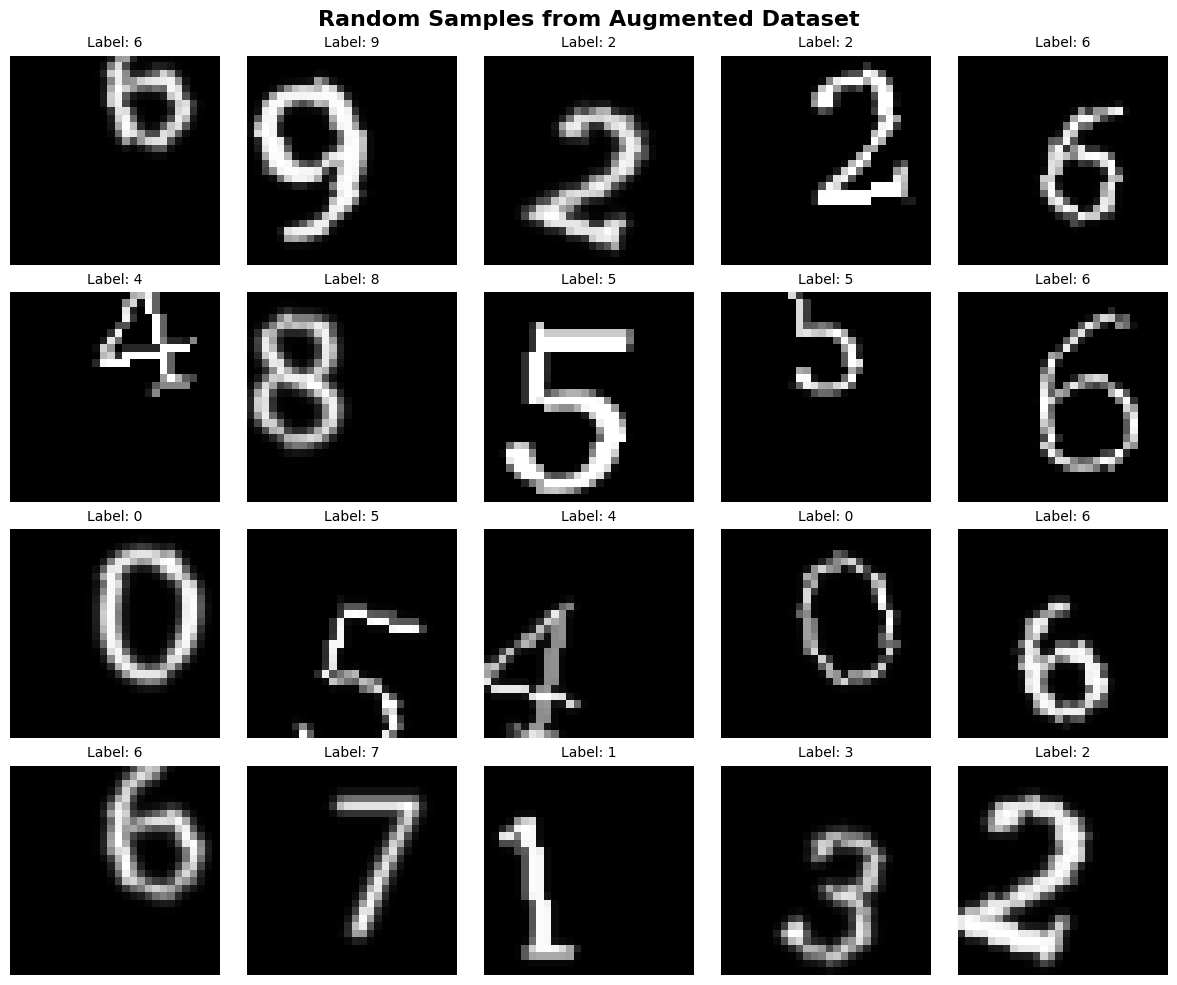

In [335]:
# Show random samples from the generated dataset
num_samples = 20
indices = random.sample(range(len(images)), num_samples)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle('Random Samples from Augmented Dataset', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, ax in enumerate(axes):
    img_idx = indices[idx]
    ax.imshow(images[img_idx], cmap='gray')
    ax.set_title(f'Label: {labels[img_idx]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 11. Dataset Statistics

Dataset Statistics
Digit 0:    15 images (10.0%)
Digit 1:    15 images (10.0%)
Digit 2:    15 images (10.0%)
Digit 3:    15 images (10.0%)
Digit 4:    15 images (10.0%)
Digit 5:    15 images (10.0%)
Digit 6:    15 images (10.0%)
Digit 7:    15 images (10.0%)
Digit 8:    15 images (10.0%)
Digit 9:    15 images (10.0%)
Total: 150 images


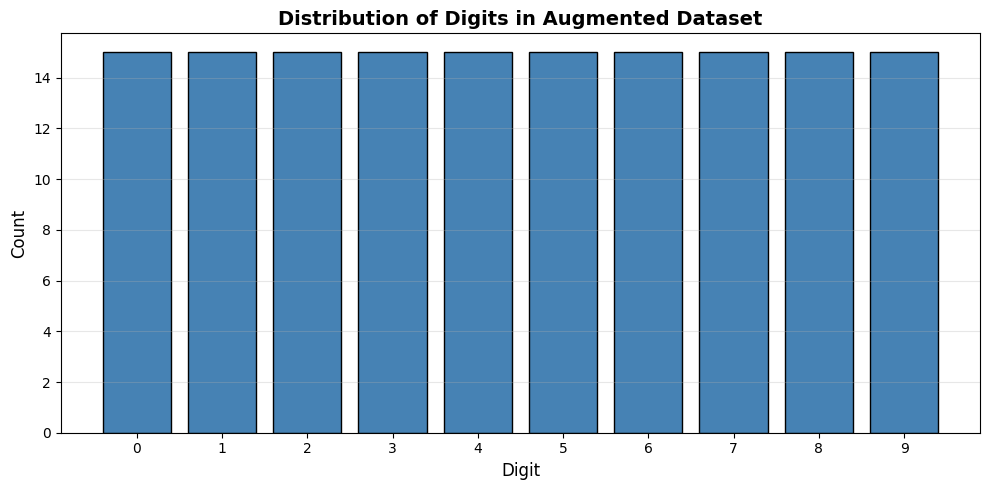

In [336]:
# Print dataset statistics
print("=" * 50)
print("Dataset Statistics")
print("=" * 50)

for digit in range(10):
    count = np.sum(labels == digit)
    percentage = (count / len(labels)) * 100
    print(f"Digit {digit}: {count:5d} images ({percentage:.1f}%)")

print("=" * 50)
print(f"Total: {len(labels)} images")

# Visualize distribution
plt.figure(figsize=(10, 5))
digit_counts = [np.sum(labels == i) for i in range(10)]
plt.bar(range(10), digit_counts, color='steelblue', edgecolor='black')
plt.xlabel('Digit', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Digits in Augmented Dataset', fontsize=14, fontweight='bold')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Save Dataset to .npz File

In [337]:
output_path = '../assets/mnist_aug.npz'

np.savez_compressed(
    output_path,
    train_images=images,
    train_labels=labels
)

file_size_mb = os.path.getsize(output_path) / 1024 / 1024

print("=" * 50)
print("✓ Dataset saved successfully!")
print("=" * 50)
print(f"File path: {output_path}")
print(f"File size: {file_size_mb:.2f} MB")
print(f"Images: {images.shape}")
print(f"Labels: {labels.shape}")
print("=" * 50)

✓ Dataset saved successfully!
File path: ../assets/mnist_aug.npz
File size: 0.03 MB
Images: (150, 28, 28)
Labels: (150,)


## 13. Verify Saved Dataset

Keys in saved file: ['train_images', 'train_labels']

Loaded images shape: (150, 28, 28)
Loaded labels shape: (150,)


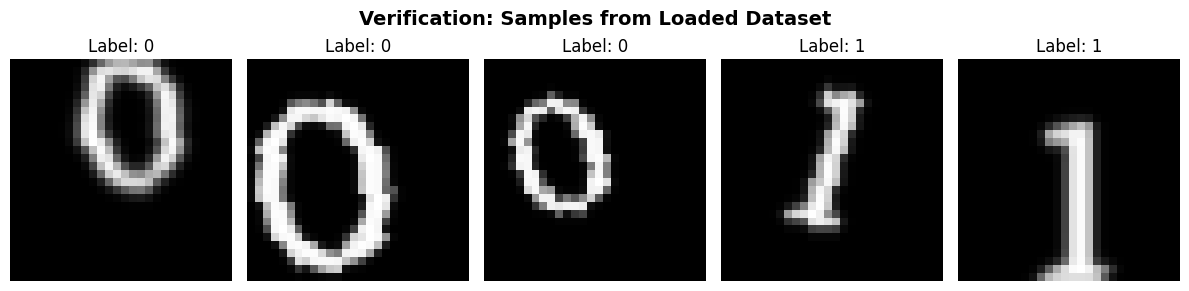


✓ Dataset verification complete!


In [338]:
# Load and verify the saved dataset
loaded_data = np.load(output_path)

print("Keys in saved file:", list(loaded_data.keys()))
print(f"\nLoaded images shape: {loaded_data['train_images'].shape}")
print(f"Loaded labels shape: {loaded_data['train_labels'].shape}")

# Display a few samples from loaded data
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle('Verification: Samples from Loaded Dataset', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes):
    ax.imshow(loaded_data['train_images'][i], cmap='gray')
    ax.set_title(f"Label: {loaded_data['train_labels'][i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Dataset verification complete!")